In [3]:
import h5py, numpy as np, matplotlib.pyplot as plt
filename = "nn_dineutron_spectrum.h5"
L = 48
by_Psq = {}

with h5py.File(filename, "r") as f:
    mN = f["mN/E0"][()]
    for gname, g in f.items():
        if gname == "mN":
            continue
        q1 = g["Psq_N1"][()][0]
        q2 = g["Psq_N2"][()][0]
        by_Psq.setdefault(q1, []).append(g["E_N1"][()])
        by_Psq.setdefault(q2, []).append(g["E_N2"][()])

Psq = np.array(sorted(by_Psq))
p2 = (2*np.pi/L)**2 * Psq
E = np.array([np.mean(by_Psq[q], axis=0) for q in Psq])
print(Psq)
print(p2)
print(E.shape)

[0 1 2 3 4]
[0.         0.01713473 0.03426946 0.05140419 0.06853892]
(5, 5001)


In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import re

rng = np.random.default_rng(1234)

filename = "nn_dineutron_spectrum.h5"
L = 48.0
 
punit = 2*np.pi/L
punit2 = punit**2


def boot_err(x):
    return np.std(x[1:], ddof=1)


def get_dE(g):
    for key in ["dE_NN", "dE", "DeltaE", "E0", "dE0"]:
        if key in g:
            return np.array(g[key])
    raise KeyError(f"No energy shift found. Keys are {list(g.keys())}")


def get_irrep(name):
    return name.split("_Psq")[0]


def get_Psq_total(name):
    m = re.search(r"Psq(\d+)", name)
    if m is None:
        raise ValueError(f"Could not read total Psq from {name}")
    return int(m.group(1))


def get_level(name):
    m = re.search(r"level(\d+)", name)
    return int(m.group(1)) if m is not None else 0


def dvec_from_d2(d2):
    nmax = int(np.ceil(np.sqrt(max(d2, 1)))) + 2
    best = None
    for nx in range(nmax + 1):
        for ny in range(nmax + 1):
            for nz in range(nmax + 1):
                v = np.array([nx, ny, nz], dtype=int)
                if int(np.dot(v, v)) == int(d2):
                    cand = tuple(sorted(v))
                    if best is None or cand < best:
                        best = cand
    if best is None:
        raise ValueError(f"No integer momentum representative found for Psq={d2}")
    return np.array(best, dtype=int)


raw_levels = []

with h5py.File(filename, "r") as f:
    mN = np.array(f["mN/E0"])
    m = float(mN[0])

    for name, g in f.items():
        if name == "mN":
            continue

        irrep = get_irrep(name)
        Psq_tot = get_Psq_total(name)
        level_index = get_level(name)

        N1 = int(np.array(g["Psq_N1"])[0])
        N2 = int(np.array(g["Psq_N2"])[0])
        dE = get_dE(g)

        E1 = np.sqrt(mN**2 + punit2*N1)
        E2 = np.sqrt(mN**2 + punit2*N2)
        E_NN = dE + E1 + E2

        E_cm = np.sqrt(E_NN**2 - punit2*Psq_tot)
        kstar2 = E_cm**2/4 - mN**2
        q2 = kstar2/punit2

        raw_levels.append({
            "name": name,
            "irrep": irrep,
            "Psq_tot": Psq_tot,
            "level_index": level_index,
            "pair": tuple(sorted((N1, N2))),
            "Ecm_boot": E_cm,
            "q2_boot": q2,
        })

raw_levels = sorted(raw_levels, key=lambda r: (r["Psq_tot"], r["irrep"], r["level_index"], r["name"]))
print([r["Psq_tot"] for r in raw_levels])



[0, 0, 1, 1, 2, 3, 4, 4]


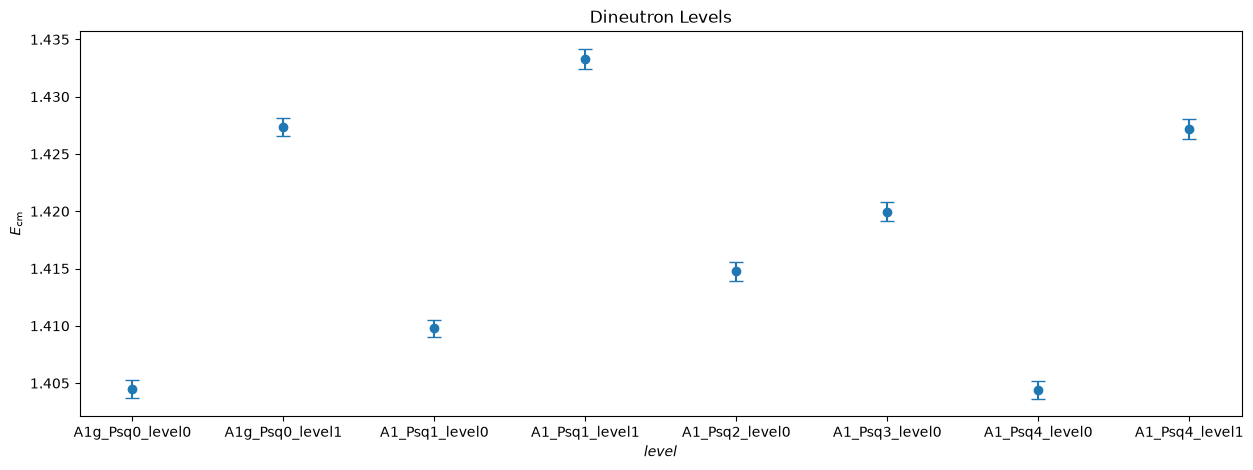

In [5]:
stdDevList = [boot_err(r["Ecm_boot"]) for r in raw_levels]

x = [r["name"] for r in raw_levels]
y = [r["Ecm_boot"][0] for r in raw_levels]


plt.figure(figsize=(15,5))
plt.errorbar(x, y, yerr=stdDevList, fmt='o', capsize=5)
plt.xlabel(r"$level$")
plt.ylabel(r"$E_{\rm cm}$")
plt.title("Dineutron Levels")
plt.show()

In [6]:
import itertools
from scipy import special as sp

'''
Finite-volume function
'''

twoPi = 2.0 * np.pi


# Let us work with ideentical particles throughout
xi = 0.5 # symmetry factor

# sqrt with branch cut aligned on positive real axis
def mySqrt(z):
   return 1j * np.sqrt( -z )

# CM momentum
def q_cm(s):
    return 0.5 * mySqrt( s - 4.0 * m **2 )

# Phase space factor
def phase_space(s):
    return xi * q_cm(s) / ( 8.0 * np.pi * np.sqrt(s) )

# inner product for two list (native)
def dot(A, B):
   return np.dot(A,B) #inner1d(A,B) #np.sum( A * B, axis=1)


def inner1d(A, B):
   return np.sum( A * B, axis=1)


# Function to generate 3-tuple "n = (nx,ny,nz)" list
# subject to the constraint nx^2 + ny^2 + nz^2 <= nShell^2,
# where "nShell" indicates the number of shells
def generateIntList( nShell ):
    intList = []
    rawList = np.array(np.arange(-nShell,nShell+1))
    for i in itertools.product(rawList,rawList,rawList):
        tmpList = np.array(i)
        if ( np.dot(tmpList,tmpList) <= nShell*nShell ):
            intList.append(tmpList)

    return np.asarray(intList)

# returns the unit vector of a vector "A"
def unit_vector( A ):
    if( all( A==0 ) ):
        return A
    else:
        return A / np.sqrt( np.dot(A,A) )

# special multiply for array of arrays (A) and an array (B), used in the zeta function
def multiply( A, B ):
   nA = len(A)
   return A.reshape(nA,1) * np.tile( B, (nA,1) )
   ### First, reshape A array to 2d (1xnA), and then copy b vector nA time to make (nA x nB) array
   ### alternatively, do (A.reshape(nA,1)).dot( B.reshape(1,3) )

# returns a Lorentz boosted four vector "(A0,A)" given some boost velocity "beta"
def lorentzBoost( A0, A, beta ):
    gamma = 1.0 / np.sqrt( 1.0 - np.dot(beta,beta) )
    Apar  = multiply( A.dot( unit_vector(beta) ), unit_vector(beta) )
    Aper  = A - Apar
    A0_prime = gamma * ( A0 - A.dot( beta ) )
    A_prime  = gamma * ( Apar - multiply( A0, beta ) ) + Aper
    return A0_prime, A_prime


# cutoff function (alpha input is dimensionless)
def cutoff( qcm_sq, kcm_sq, alpha, L ):
    alpha = (L / twoPi)**2 * alpha  # convert to dimensionfull units
    return np.exp( -alpha * ( kcm_sq - qcm_sq ) )

#
# KSS Zeta function for ell = m_ell = 0, given "qcm_sq", total momentum "nP"
# This function is in units of L / 2pi, e.g. m1 -> m1 * L / (2 * pi).
#

# Finite volume function F, given Ecm (units of mass), nP, alpha (dimensionless), and L (units of mass)
# MUST call generateIntList first and use global intList from its output
#
# Note: We chose to have Ecm as input rather than E for convenience in plotting/ pole finding. Coding it the other way works too,
# we are just saving ourselves a couple transformations which are not needed for our purposes.
#
def F_function( Ecm, nP, alpha, L ):
    P = twoPi * nP / L                               # P = (2*pi/L)* nP
    P_sq = np.dot(P,P)                              # P^2
    E = np.sqrt( Ecm**2 + P_sq )                    # compute E given Ecm and P
    s = Ecm**2
    eps = 1e-16
    qcm = q_cm(s+1j*eps)
    qcm_sq = qcm**2
    rho = phase_space(s+1j*eps)
    beta = P/E                                      # boost velocity

    k = (twoPi / L) * intList
    omega = np.sqrt( m_sq + inner1d(k,k) )
    omega_cm, k_cm = lorentzBoost( omega, k, beta )
    tmp = cutoff( qcm_sq, inner1d(k_cm,k_cm), alpha, L ) * omega_cm / omega
    tmp = tmp / ( qcm_sq - inner1d(k_cm,k_cm ) )
    sum0 = ( xi / (2.0 * Ecm * L**3) ) * np.sum( tmp )

    alpha = (L / twoPi)**2 * alpha  # convert to dimensionfull units
    z   = np.sqrt( alpha ) * qcm
    integral = ( xi / (4.0 * np.pi**2 * Ecm )) * ( ( np.sqrt( 0.25 * np.pi / alpha ) ) * np.exp( alpha * qcm_sq ) - 0.5 * np.pi * qcm * sp.erfi( z ) )

    return  1j * rho + sum0.real + integral # taking real part of sum to remove imaginary artifact at threshold


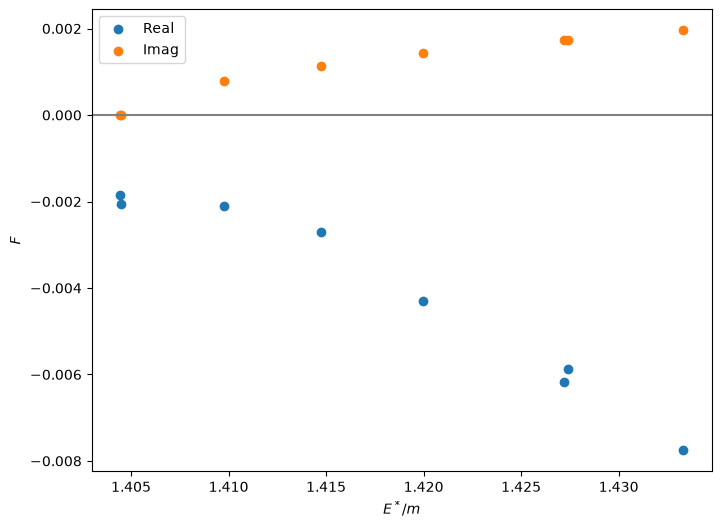

In [7]:
nShell = 15
L = 48.0
alpha = 0.125

intList = generateIntList( nShell )



E_values = []
F_real = []
F_imag = []

for level in raw_levels:

    Ecm = float(level["Ecm_boot"][0])

    m = float(mN[0]) 
    m_sq = m**2


    nP = dvec_from_d2(level["Psq_tot"]) 

    value = F_function(Ecm, nP, alpha, L)

    E_values.append(Ecm)

    F_real.append(np.real(value))
    F_imag.append(np.imag(value))

plt.figure(figsize=(8,6))

plt.scatter(E_values, F_real, label="Real")
plt.scatter(E_values, F_imag, label="Imag")

plt.axhline(0,color="gray")

plt.xlabel(r"$E^*/m$")
plt.ylabel(r"$F$")

plt.legend()

plt.show()

In [8]:
M_values = []
qcot_values = []
eps = 1e-16

for level in raw_levels:

    # Central bootstrap values
    Ecm = float(level["Ecm_boot"][0])
    q2 = level["q2_boot"][0]

    # Total momentum vector
    nP = dvec_from_d2(level["Psq_tot"]) 
    # Finite-volume function (takes Ecm directly, same convention as the F(Ecm,P,L) cell above)
    Fvalue = F_function(Ecm, nP,alpha, L)

    # # Phase-space factor
    # rho = Rho(Ecm)

    # Scattering amplitude
    M = -1 / (Fvalue)

    print(Ecm)
    #print(q)
    print(m)
    # q cot(delta)
    #qcot = np.real(8*np.pi*Ecm / M)

    # Store results
    M_values.append(M)
    #qcot_values.append(qcot)


1.404480193149725
0.7026827020795523
1.427387430256371
0.7026827020795523
1.4097814949159677
0.7026827020795523
1.4333221966427518
0.7026827020795523
1.4147421255240087
0.7026827020795523
1.4199751076807943
0.7026827020795523
1.4044221450218684
0.7026827020795523
1.4271811314910883
0.7026827020795523


In [9]:

# plt.figure(figsize=(12, 5))
# ax1 = plt.gcf().add_subplot(121)
# ax2 = plt.gcf().add_subplot(122)

# ax1.scatter(q2_values, np.real(M_values), label="Real part of M")
# ax1.set_xlabel("q^2")
# ax1.set_ylabel("M")
# ax1.set_title("Real part of M vs q^2")

# ax2.scatter(q2_values, np.imag(M_values), label="Imaginary part of M", color = 'red')
# ax2.set_xlabel("q^2")
# ax2.set_ylabel("M")
# ax2.set_title("Imaginary part of M vs q^2")

In [10]:
m = float(mN[0])
L=48
e_cm_inputs = np.linspace(2 *m, 10.2 * m, 8000)
shell = 20
alpha = 0.125
intList = generateIntList(shell)
P = np.array([0.0, 0.0, 0.0])

linspace_F_values = []

linspace_F_Real_values = []
linspace_F_Imag_values = []

linspace_M_real_values = []
linspace_M_imag_values= []

def M_function(F):
    return -1 / F

for i in range(len(e_cm_inputs)):
    to_append_linspace_F = F_function(e_cm_inputs[i], P, alpha, L)
    linspace_F_values.append(to_append_linspace_F)

    to_append_linspace_F_Real = linspace_F_values[i].real
    linspace_F_Real_values.append(to_append_linspace_F_Real)    
    
    to_append_linspace_F_Imag = linspace_F_values[i].imag
    linspace_F_Imag_values.append(to_append_linspace_F_Imag)

    to_append_linspace_M_real = (M_function(linspace_F_values[i])).real
    linspace_M_real_values.append(to_append_linspace_M_real)

    to_append_linspace_M_imag = (M_function(linspace_F_values[i])).imag
    linspace_M_imag_values.append(to_append_linspace_M_imag)

c:\Users\shing\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\matplotlib\cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\shing\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\matplotlib\cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


Text(0.5, 1.0, 'F vs E^*/m')

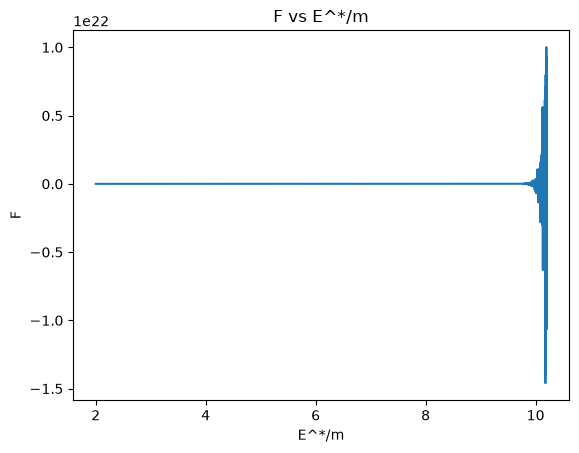

In [11]:
plt.plot(e_cm_inputs / m, linspace_F_values)

plt.xlabel("E^*/m")
plt.ylabel("F")
plt.title("F vs E^*/m")

(1.9, 4.0)

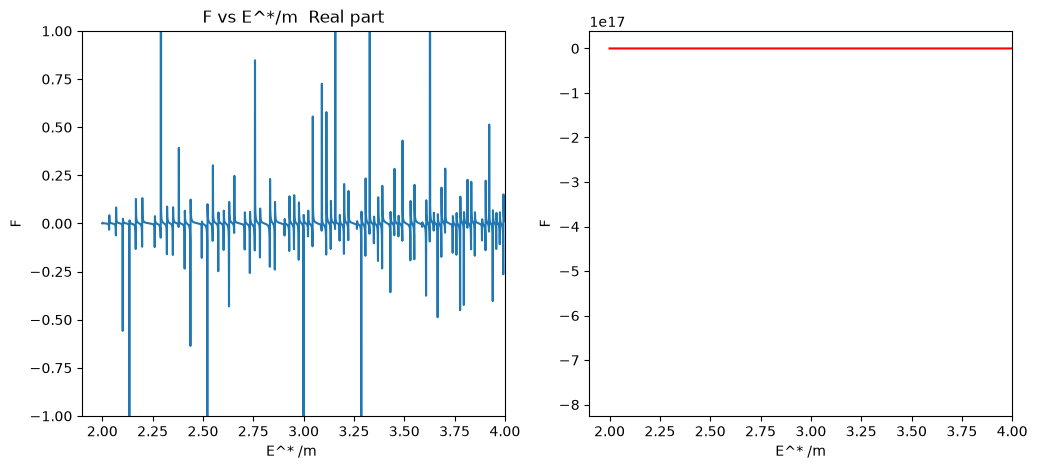

In [12]:
plt.figure(figsize=(12, 5))
f_e_real = plt.gcf().add_subplot(121)
f_e_imag = plt.gcf().add_subplot(122)


f_e_real.plot(e_cm_inputs / m, linspace_F_Real_values, label="Real part of F")
f_e_real.set_xlabel("E^* /m ")
f_e_real.set_ylabel("F")
f_e_real.set_title("F vs E^*/m  Real part")
f_e_real.set_xlim(1.9, 4.0)
f_e_real.set_ylim(-1, 1)


f_e_imag.plot(e_cm_inputs / m , linspace_F_Imag_values, label="Imaginary part of F", color = 'red')
f_e_imag.set_xlabel("E^* /m")
f_e_imag.set_ylabel("F")
#ax6.set_title("F vs E^*/m Imaginary part")
f_e_imag.set_xlim(1.9, 4.0)



Code to test F Function Graphically 

179


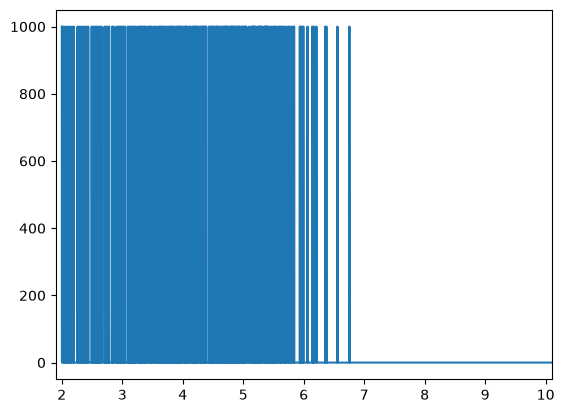

In [13]:

import numpy as np
import matplotlib.pyplot as plt


L = 48

d = np.array([0, 0, 0])
punit = 2 * np.pi / L
Pvec = punit * d
P2 = np.dot(Pvec, Pvec)

E_min = 2 * m
E_max = 10 * m

levels = []

E_grid = np.linspace(2 * m, 10.2 * m, 8000)
F = np.zeros_like(E_grid)


maxShell = 10
for i in range(-maxShell, maxShell + 1):
    for j in range(-maxShell, maxShell + 1):
        for k in range(-maxShell, maxShell + 1):

            n1 = np.array([i, j, k])
            n2 = d - n1

            p1 = punit * n1
            p2 = punit * n2

            E_lab = (np.sqrt(np.dot(p1, p1) + m**2) +
                     np.sqrt(np.dot(p2, p2) + m**2))
           
            E_star = np.sqrt(E_lab**2 - P2)
            levels.append(E_star)

levels = np.unique(np.round(levels, 12))

for E_star in levels:
    idx = np.argmin(np.abs(E_grid - E_star))
    F[idx] = 1000 #np.inf

print(len(levels))

plt.plot(E_grid / m, F)
plt.xlim(1.9, 10.1)
plt.show()

(-1.0, 1.0)

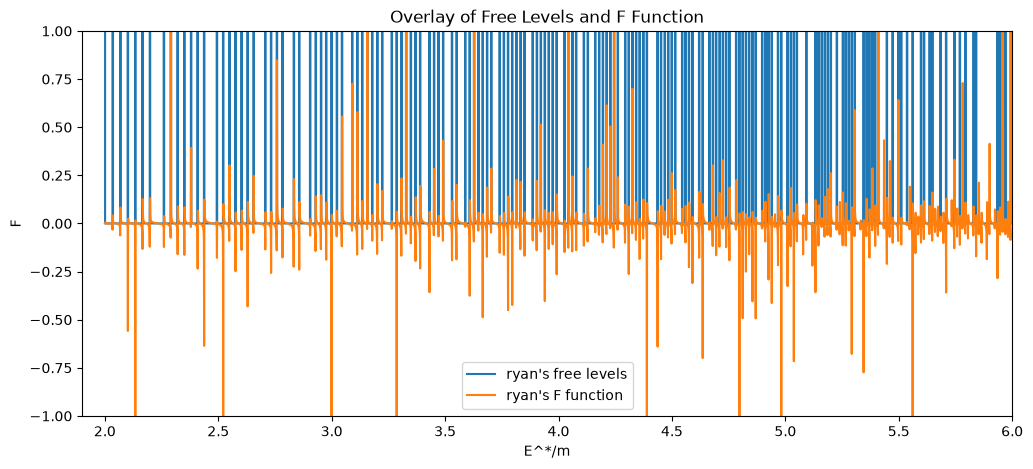

In [14]:
plt.figure(figsize=(12, 5))
overlayed = plt.gcf().add_subplot()

overlayed.plot(E_grid/m,F, label = "ryan's free levels")
overlayed.plot(e_cm_inputs/m, linspace_F_Real_values, label = "ryan's F function")

overlayed.set_xlabel("E^*/m")
overlayed.set_ylabel("F")
overlayed.set_title("Overlay of Free Levels and F Function")
overlayed.legend()
overlayed.set_xlim(1.9,6.0)
overlayed.set_ylim(-1, 1)

45


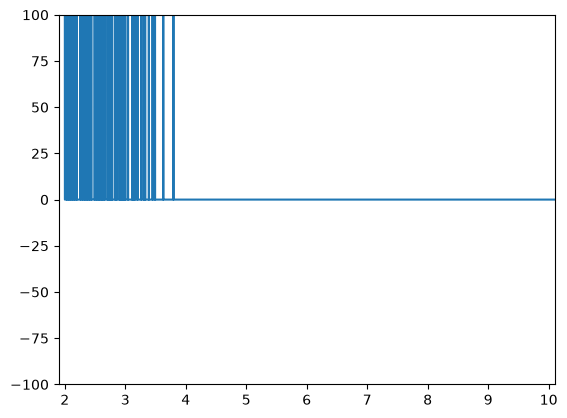

In [15]:
import numpy as np
import matplotlib.pyplot as plt

m = float(mN[0])
L = 48

d = np.array([0, 0, 0])
punit = 2 * np.pi / L
Pvec = punit * d
P2 = np.dot(Pvec, Pvec)

E_min = 2 * m
E_max = 10 * m

levels = []

E_grid = np.linspace(2 * m, 10.2 * m, 8000)
F = np.zeros_like(E_grid)

for i in range(-5, 6):
    for j in range(-5, 6):
        for k in range(-5, 6):

            n1 = np.array([i, j, k])
            n2 = d - n1

            p1 = punit * n1
            p2 = punit * n2

            E_lab = (np.sqrt(np.dot(p1, p1) + m**2) +
                     np.sqrt(np.dot(p2, p2) + m**2))
           
            E_star = np.sqrt(E_lab**2 - P2)
            levels.append(E_star)

levels = np.unique(np.round(levels, 12))

for E_star in levels:
    idx = np.argmin(np.abs(E_grid - E_star))
    F[idx] = 1000 #np.inf

print(len(levels))

plt.plot(E_grid / m, F)
plt.ylim(-100,100)
plt.xlim(1.9, 10.1)
plt.show()


Fitting A and R for F Function

In [16]:
a_values = []
r_values = []

E_values = []
Q_values = []

observedValues = []
predictedValues = []

def F_Transformation(Function):
    return -Function* (8*np.pi*Ecm) /xi  + 1j* q

alpha = 0.125
eps = 1e-16


for level in raw_levels:
    Ecm = float(level["Ecm_boot"][0])

    # m = float(mN[0])
    m_sq = m**2

    nP = dvec_from_d2(level["Psq_tot"]) 

    value = F_function(Ecm, nP, alpha, L)

    E_values.append(Ecm)

    q = q_cm(Ecm**2 + 1j*eps)
    Q_values.append(q)


    F_transformed = F_Transformation(value)
    observedValues.append(F_transformed)


# def predictedValuesChi(a, r):
#     for Ecm in E_values:
#         q = q_cm(Ecm**2 + 1j*eps)
#         predictedValues.append((1/a) + 0.5 * r * q**2)


def predictedValuesChi(a, r):
    return np.array([
        -(1/a) + 0.5*r*q_cm(Ecm**2 + 1j*eps)**2
        for Ecm in E_values
    ])

In [17]:
from scipy.optimize import minimize

def chi_squared(params):
    a, r = params
    predicted = predictedValuesChi(a, r)
    observed = np.array(observedValues)
    residual = observed - predicted
    return np.sum(residual.real**2 + residual.imag**2)

lowest_chi2 = np.inf
best_result = None
predictedFValues = None

n_samples = 500
n_range = 10000
a_values = np.random.uniform(low=-n_range, high=n_range, size=n_samples)
r_values = np.random.uniform(low=-n_range, high=n_range, size=n_samples)

for k in range(len(a_values)):
    a_temp = a_values[k]
    r_temp = r_values[k]
    initial_guess = [a_temp, r_temp]
    result = minimize(chi_squared, initial_guess, method="Nelder-Mead")
    if result.fun < lowest_chi2:
        lowest_chi2 = result.fun
        best_result = result
        predictedFValues = predictedValuesChi(*best_result.x)  # use optimized a, r, not the seed

a_opt, r_opt = best_result.x
print(f"Optimal a = {a_opt:.6f}")
print(f"Optimal r = {r_opt:.6f}")
print(f"Minimum chi^2 = {best_result.fun:.6f}")
print(predictedFValues)

Optimal a = -10.065221
Optimal r = 43.122289
Minimum chi^2 = 0.005888
[0.08594473+5.39028606e-16j 0.435614  +5.39028606e-16j
 0.16636375+5.39028606e-16j 0.52712836+5.39028606e-16j
 0.24188931+5.39028606e-16j 0.32184894+5.39028606e-16j
 0.08506583+5.39028606e-16j 0.43243969+5.39028606e-16j]


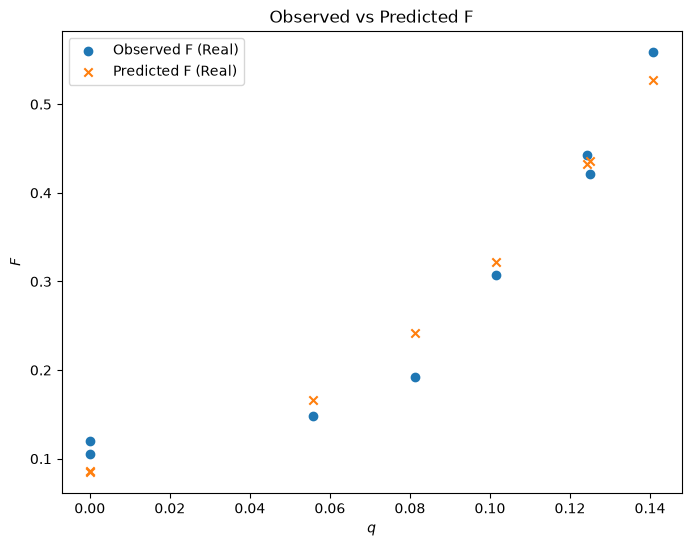

In [18]:
q_real = np.real(Q_values)

plt.figure(figsize=(8,6))
plt.scatter(q_real, np.real(observedValues), marker='o', label='Observed F (Real)')
plt.scatter(q_real, np.real(predictedFValues), marker='x', label='Predicted F (Real)')

plt.xlabel(r"$q$")
plt.ylabel(r"$F$")
plt.title("Observed vs Predicted F")
plt.legend()
plt.show()

Fitting A and R for energy levels 

In [19]:
QSquared_Values = [q**2 for q in Q_values]
nP_list = [dvec_from_d2(level["Psq_tot"]) for level in raw_levels]
Ecm_obs = np.array([float(level["Ecm_boot"][0]) for level in raw_levels])
sigma_Ecm = np.array([boot_err(r["Ecm_boot"]) for r in raw_levels])

expected_zeros = [2,2,1,1,2]

In [20]:
from collections import defaultdict

sector_data = defaultdict(lambda: {"nP": None, "Ecm": [], "sigma": []})

for level in raw_levels:
    key = level["Psq_tot"]
    if sector_data[key]["nP"] is None:
        sector_data[key]["nP"] = dvec_from_d2(level["Psq_tot"])
    sector_data[key]["Ecm"].append(float(level["Ecm_boot"][0]))
    sector_data[key]["sigma"].append(boot_err(level["Ecm_boot"]))

# sort each sector's levels by energy (level0 < level1, etc.)
for key in sector_data:
    order = np.argsort(sector_data[key]["Ecm"])
    sector_data[key]["Ecm"] = np.array(sector_data[key]["Ecm"])[order]
    sector_data[key]["sigma"] = np.array(sector_data[key]["sigma"])[order]

Ecm_scan_min = Ecm_obs.min()
Ecm_scan_max = Ecm_obs.max()

for key, info in sector_data.items():
    print(f"Psq_tot={key}: nP={info['nP']}, {len(info['Ecm'])} level(s), Ecm={info['Ecm']}")

Psq_tot=0: nP=[0 0 0], 2 level(s), Ecm=[1.40448019 1.42738743]
Psq_tot=1: nP=[0 0 1], 2 level(s), Ecm=[1.40978149 1.4333222 ]
Psq_tot=2: nP=[0 1 1], 1 level(s), Ecm=[1.41474213]
Psq_tot=3: nP=[1 1 1], 1 level(s), Ecm=[1.41997511]
Psq_tot=4: nP=[0 0 2], 2 level(s), Ecm=[1.40442215 1.42718113]


In [21]:
def free_particle_poles(nP, L, m, maxShell=15):
    punit_ = 2*np.pi/L
    nP_arr = np.array(nP, dtype=float)
    Pvec = punit_*nP_arr
    P2_ = np.dot(Pvec, Pvec)
    levels = []
    for i in range(-maxShell, maxShell+1):
        for j in range(-maxShell, maxShell+1):
            for k in range(-maxShell, maxShell+1):
                n1 = np.array([i,j,k]); n2 = nP_arr - n1
                p1, p2 = punit_*n1, punit_*n2
                E_lab = np.sqrt(p1@p1+m**2) + np.sqrt(p2@p2+m**2)
                levels.append(np.sqrt(E_lab**2 - P2_))
                
    return np.unique(np.round(levels, 10))

pole_Dict_All = {}
for Psq, info in sector_data.items():
    if Psq not in pole_Dict_All:
        pole_Dict_All[Psq] = free_particle_poles(info["nP"], L, m)

for Psq in range(5):
    print(Psq)
    print(f"Psq = {Psq}, # of poles = {len(pole_Dict_All[Psq])}")

0
Psq = 0, # of poles = 402
1
Psq = 1, # of poles = 1920
2
Psq = 2, # of poles = 3301
3
Psq = 3, # of poles = 2435
4
Psq = 4, # of poles = 2040


In [54]:
from scipy.optimize import brentq


def mySqrt_vectorized(z):
    z = np.asarray(z, dtype=complex)
    return 1j * np.sqrt(-z)

def q_cm_vectorized(s):
    return 0.5 * mySqrt_vectorized(s - 4.0 * m**2)


def M_using_a_r(Ecm, a, r):
    s = Ecm**2
    qcm = q_cm_vectorized(s)
    effective_range = (-1/a) + 0.5 * r * (qcm**2)
    return (8.0 * np.pi * np.sqrt(s)) / (xi * (effective_range - (1j * qcm)))

def quantization_condition(Ecm, a, r, nP):
    # eps = 1e-16
    # s = Ecm**2 + 1j*eps
    # qCotDelta = -1/a + 0.5*r*q_cm(s)**2
    # Kinverse = xi * qCotDelta / (8*np.pi*Ecm)   <----- 2 ways to implment quantization condition. Comment out 1
    # Fpv = F_function(Ecm, nP, alpha, L).real   
    # return (Kinverse + Fpv).real
   
   
    FValues = F_function(Ecm,nP,alpha,L)
    MValues = M_using_a_r(Ecm,a,r)                 #<----- 2 ways to implment quantization condition. Comment out 1
    return np.real(1/MValues + FValues)



In [55]:

Ecm_grid_min = min(info["Ecm"].min() for info in sector_data.values()) -0.005
Ecm_grid = np.linspace(Ecm_grid_min, Ecm_scan_max, 5000)

F_grid_by_Psq = {}
for Psq, info in sector_data.items():
    F_grid_by_Psq[Psq] = np.array([F_function(Ecm, info["nP"], alpha, L) for Ecm in Ecm_grid])


# def quantization_grid(a, r, Psq):
#     s = Ecm_grid**2
#     qcm = q_cm(s + 1j*1e-16)
#     qCotDelta = -1/a + 0.5*r*qcm**2
#     Kinverse = xi * qCotDelta / (8*np.pi*Ecm_grid)
#     Fpv = F_grid_by_Psq[Psq].real
#     return (Kinverse + Fpv).real



In [56]:
#Precompute F values
F_by_Psq = {}

for Psq_tot in range(5):
    nP = dvec_from_d2(Psq_tot)

    F_by_Psq[Psq_tot] = np.array([
        F_function(Ecm, nP, alpha, L)
        for Ecm in Ecm_grid
    ])

def quantization_grid(a, r, Psq_tot):
    M_values = M_using_a_r(Ecm_grid, a, r)
    F_values = F_by_Psq[Psq_tot]

    return np.real(
        1.0 / M_values + F_values
    )

In [58]:


def find_zeros_in_grid(quantization_values, energies, poles,Psq):
    zeros = []
    for i in range(len(energies) - 1):
        f1, f2 = quantization_values[i], quantization_values[i+1]
        e1, e2 = energies[i], energies[i+1]
        if not (np.isfinite(f1) and np.isfinite(f2)):
            continue
        if np.sign(f1) == np.sign(f2):
            continue
        if np.any((poles >= e1) & (poles <= e2)):
            continue   
        if(len(zeros)>= expected_zeros[Psq]):
            continue
        slope = (f2 - f1) / (e2 - e1)
        zeros.append(e1 - f1/slope)
    return np.array(zeros)



In [59]:
def match_chi_squared(zeros, obs_Ecm, obs_sigma):
    zeros = list(zeros)
    chi2 = 0.0
    residuals = []

    for E_obs, sigma in sorted(zip(obs_Ecm, obs_sigma)):
        if not zeros:
            return np.inf, residuals
        closest = min(zeros, key=lambda z: abs(z - E_obs))
        residual = closest - E_obs
        residuals.append(residual)
        chi2 += (residual / sigma)**2
        zeros.remove(closest)
    return chi2, residuals


def total_chi_squared(params, collect_residuals=None):
    a, r = params
    total = 0.0
    for Psq, info in sector_data.items():
        quant_values = quantization_grid(a, r, Psq)
        zeros = find_zeros_in_grid(quant_values, Ecm_grid, pole_Dict_All[Psq],Psq)
        if len(zeros) < len(info["Ecm"]):
            return np.inf
        chi2_sector, residuals = match_chi_squared(zeros, info["Ecm"], info["sigma"])
        total += chi2_sector
        if collect_residuals is not None:
            collect_residuals.extend(residuals)
    return total


fillerAandR = [-9, 38]
residual_list = []
result = total_chi_squared(fillerAandR, collect_residuals=residual_list)
print(len(residual_list))   

8


In [60]:

from scipy.optimize import minimize
lowest_chi2_for_E = np.inf
n_samples = 10
n_range = 50
a_values = np.random.uniform(low=-n_range, high=n_range, size=n_samples)
r_values = np.random.uniform(low=-n_range, high=n_range, size=n_samples)

for k in range(len(a_values)):
    a_temp = a_values[k]
    r_temp = r_values[k]
    initial_guess = [a_temp, r_temp]
    # initial_guess = [-8, 37]
    result = minimize(total_chi_squared, initial_guess, method="Nelder-Mead")
    if result.fun < lowest_chi2_for_E:
        lowest_chi2_for_E = result.fun
        best_result = result
a_opt, r_opt = result.x
print(f"chi^2 = {result.fun:.6f}, success = {result.success}, a = {a_opt:.6f}, r = {r_opt:.6f}")
print(len(residual_list))

c:\Users\shing\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\optimize\_optimize.py:870: RuntimeWarning: invalid value encountered in subtract
  np.max(np.abs(fsim[0] - fsim[1:])) <= fatol):


chi^2 = 0.515823, success = True, a = -9.973624, r = 40.430015
8


In [ ]:
best_a, best_r = result.x
a_fit, r_fit = result.x


print("chi-squared =", result.fun)
print("success =", result.success)
print("message =", result.message)
print("Best fit:")
print("a =", best_a)
print("r =", best_r)
print()

for Psq in range(5):

    print("Psq =", Psq)

    quantization_values = quantization_grid(
        best_a,
        best_r,
        Psq
    )

    zeros = find_zeros_in_grid(
        quantization_values,
        Ecm_grid,
        pole_Dict_All[Psq],
        Psq
    )

    print("Predicted roots:")
    print(zeros)
    print(f"found {len(zeros)} roots. Expected {expected_zeros[Psq]}")


    # print("Measured levels:")
    # print(measured_by_Psq[Psq_tot])
    print("----------------------------")

chi-squared = 0.5158230405815238
success = True
message = Optimization terminated successfully.
Best fit:
a = -9.973623800663415
r = 40.43001495791153

Psq = 0
Predicted roots:
[1.4042776  1.42735531]
found 2 roots. Expected 2
----------------------------
Psq = 1
Predicted roots:
[1.4099007  1.43307808]
found 2 roots. Expected 2
----------------------------
Psq = 2
Predicted roots:
[1.415171]
found 1 roots. Expected 1
----------------------------
Psq = 3
Predicted roots:
[1.41998852]
found 1 roots. Expected 1
----------------------------
Psq = 4
Predicted roots:
[1.40429499 1.42704109]
found 2 roots. Expected 2
----------------------------


In [62]:
a_test, r_test = -8, 37
for Psq, info in sector_data.items():
    quant_values = quantization_grid(a_test, r_test, Psq)
    zeros = find_zeros_in_grid(quant_values, Ecm_grid, pole_Dict_All[Psq],Psq)
    print(f"Psq={Psq}: expected {len(info['Ecm'])}, found {len(zeros)}")

Psq=0: expected 2, found 2
Psq=1: expected 2, found 2
Psq=2: expected 1, found 1
Psq=3: expected 1, found 1
Psq=4: expected 2, found 2


Finding Chi-Squared using correlated Data

Covariance Matrix w/0 np.cov: 

In [ ]:
arrayLen = len(raw_levels[0]["Ecm_boot"]) - 1  

Ecm_matrix = np.array([level["Ecm_boot"][1:] for level in raw_levels])
deviations = Ecm_matrix - Ecm_matrix.mean(axis=1, keepdims=True)   # deviate from sample mean, not central value
cov_matrix = (deviations @ deviations.T) / (arrayLen - 1)


cov_inv = np.linalg.inv(cov_matrix)
# print(cov_matrix.shape)  
# for i, level in enumerate(raw_levels):
#     print(np.sqrt(cov_matrix[i,i]), boot_err(level["Ecm_boot"]))


Covariance Matrix w/ np.cov. Between the code above and below, comment out one of the two cov_matrix.

In [ ]:
# bootstrap_matrix = []

# for level in raw_levels:
#     bootstrap_samples = level["Ecm_boot"][1:]
#     bootstrap_matrix.append(bootstrap_samples)

# bootstrap_matrix = np.array(bootstrap_matrix)

# cov_matrix = np.cov(bootstrap_matrix)

In [64]:
def build_residual_vector(a, r):
    residuals = np.zeros(len(raw_levels))
    zeros_by_Psq = {}
    for Psq in set(level["Psq_tot"] for level in raw_levels):
        quant_values = quantization_grid(a, r, Psq)
        zeros_by_Psq[Psq] = list(find_zeros_in_grid(quant_values, Ecm_grid, pole_Dict_All[Psq],Psq))

    for i, level in enumerate(raw_levels):
        Psq = level["Psq_tot"]
        E_obs = float(level["Ecm_boot"][0])
        candidates = zeros_by_Psq[Psq]
        if not candidates:
            return None   
        closest = min(candidates, key=lambda z: abs(z - E_obs))
        residuals[i] = closest - E_obs
        candidates.remove(closest)

    print(residuals)
    return residuals

build_residual_vector(-9,37)

[-1.15669769e-04 -1.18067609e-04  1.57931952e-04 -3.57093794e-04
  4.20408360e-04 -5.65687694e-05 -4.17573470e-05 -2.21341471e-04]


array([-1.15669769e-04, -1.18067609e-04,  1.57931952e-04, -3.57093794e-04,
        4.20408360e-04, -5.65687694e-05, -4.17573470e-05, -2.21341471e-04])

In [65]:
def chi_squared_correlated(params):
    a, r = params
    residuals = build_residual_vector(a, r)
    if residuals is None:
        return np.inf
    return residuals @ cov_inv @ residuals

In [72]:
from scipy.optimize import minimize
lowest_chi2_for_E = np.inf
n_samples = 10
n_range = 50
a_values_Cov = np.random.uniform(low=-n_range, high=n_range, size=n_samples)
r_values_C0v = np.random.uniform(low=-n_range, high=n_range, size=n_samples)

for k in range(len(a_values)):
    a_temp_Cov = a_values[k]
    r_temp_Cov = r_values[k]
    initial_guess = [a_temp_Cov, r_temp_Cov]
    result_Cov = minimize(chi_squared_correlated, initial_guess, method="Nelder-Mead")
    if result.fun < lowest_chi2_for_E:
        lowest_chi2_for_E = result.fun
        best_result = result_Cov

[-0.00054265 -0.01126771 -0.00197609 -0.01341879 -0.0046756  -0.00867062
 -0.00046624 -0.01115007]
[-0.00056538 -0.01140002 -0.00203533 -0.01353068 -0.00477404 -0.00879407
 -0.00048878 -0.01128163]
[-0.00053898 -0.01143022 -0.00199253 -0.01360501 -0.00472832 -0.0087541
 -0.00046264 -0.01131034]
[-0.00056926 -0.01123471 -0.00201877 -0.01334075 -0.00472083 -0.00870964
 -0.00049258 -0.01111864]
[-0.00058414 -0.01112824 -0.00203016 -0.01319885 -0.00471346 -0.00868209
 -0.00050728 -0.01101421]
[-0.00056184 -0.01099972 -0.00197302 -0.01308887 -0.00461841 -0.00856225
 -0.00048517 -0.01088645]
[-0.00055986 -0.01079173 -0.0019413  -0.01285714 -0.00453857 -0.00844208
 -0.00048315 -0.01068121]
[-0.00060186 -0.01062871 -0.0019931  -0.01260718 -0.0045701  -0.00844247
 -0.0005247  -0.01052232]
[-0.00063133 -0.01026451 -0.00199601 -0.01214541 -0.00450321 -0.00830433
 -0.00055379 -0.0101647 ]
[-0.00060835 -0.0099178  -0.00191206 -0.01177872 -0.00433347 -0.00806389
 -0.00053094 -0.00982217]
[-0.0006210

c:\Users\shing\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scipy\optimize\_optimize.py:870: RuntimeWarning: invalid value encountered in subtract
  np.max(np.abs(fsim[0] - fsim[1:])) <= fatol):


[-0.00097025 -0.00210184 -0.00116309 -0.00239919 -0.00158383 -0.00293214
 -0.0008849  -0.00215944]
[-0.00100908 -0.00213492 -0.00120697 -0.00242748 -0.00163641 -0.00299444
 -0.00092318 -0.00219229]
[-0.00098729 -0.00195026 -0.00112984 -0.00223254 -0.00148887 -0.00276363
 -0.00090145 -0.00201098]
[-0.00094515 -0.00191671 -0.0010838  -0.00220382 -0.00143456 -0.00269966
 -0.00085992 -0.00197769]
[-0.00090822 -0.00181007 -0.00101885 -0.00209506 -0.00133171 -0.0025516
 -0.00082341 -0.00187284]
[-0.0009237  -0.00167611 -0.00098752 -0.00194756 -0.00124486 -0.00239823
 -0.00083844 -0.00174179]
[-0.00089325 -0.00148592 -0.00089848 -0.00174687 -0.00108292 -0.00214846
 -0.00080817 -0.0015554 ]
[-0.00078975 -0.001352   -0.00077236 -0.00161753 -0.00091665 -0.00193161
 -0.00070616 -0.00142361]
[-0.00064704 -0.00107041 -0.00056629 -0.00133222 -0.000616   -0.00151149
 -0.00056538 -0.0011476 ]
[-0.00059347 -0.00082149 -0.0004403  -0.00106659 -0.00039615 -0.00117255
 -0.00051236 -0.00090493]
[-3.2839388

In [73]:
a_opt, r_opt = result_Cov.x
print(f"chi^2 = {result_Cov.fun:.6f}, success = {result_Cov.success}, a = {a_opt:.6f}, r = {r_opt:.6f}")


chi^2 = 3.828663, success = True, a = -13.317728, r = 37.265210


In [74]:
best_a, best_r = result.x
a_fit, r_fit = result.x


print("chi-squared =", result.fun)
print("success =", result.success)
print("message =", result.message)
print("Best fit:")
print("a =", best_a)
print("r =", best_r)
print()

totalZeros = 0
totalExpectedZeros = 0

for Psq in range(5):

    print("Psq =", Psq)

    quantization_values = quantization_grid(
        best_a,
        best_r,
        Psq
    )

    zeros = find_zeros_in_grid(
        quantization_values,
        Ecm_grid,
        pole_Dict_All[Psq],
        Psq
    )

    print("Predicted roots:")
    print(zeros)
    totalZeros += len(zeros)
    print(f"found {len(zeros)} roots. Expected {expected_zeros[Psq]}")
    totalExpectedZeros += expected_zeros[Psq]

    # print("Measured levels:")
    # print(measured_by_Psq[Psq_tot])
    print("----------------------------")

print(f"found {totalZeros} roots. Expected {totalExpectedZeros}")


chi-squared = 0.5158230405815238
success = True
message = Optimization terminated successfully.
Best fit:
a = -9.973623800663415
r = 40.43001495791153

Psq = 0
Predicted roots:
[1.4042776  1.42735531]
found 2 roots. Expected 2
----------------------------
Psq = 1
Predicted roots:
[1.4099007  1.43307808]
found 2 roots. Expected 2
----------------------------
Psq = 2
Predicted roots:
[1.415171]
found 1 roots. Expected 1
----------------------------
Psq = 3
Predicted roots:
[1.41998852]
found 1 roots. Expected 1
----------------------------
Psq = 4
Predicted roots:
[1.40429499 1.42704109]
found 2 roots. Expected 2
----------------------------
found 8 roots. Expected 8


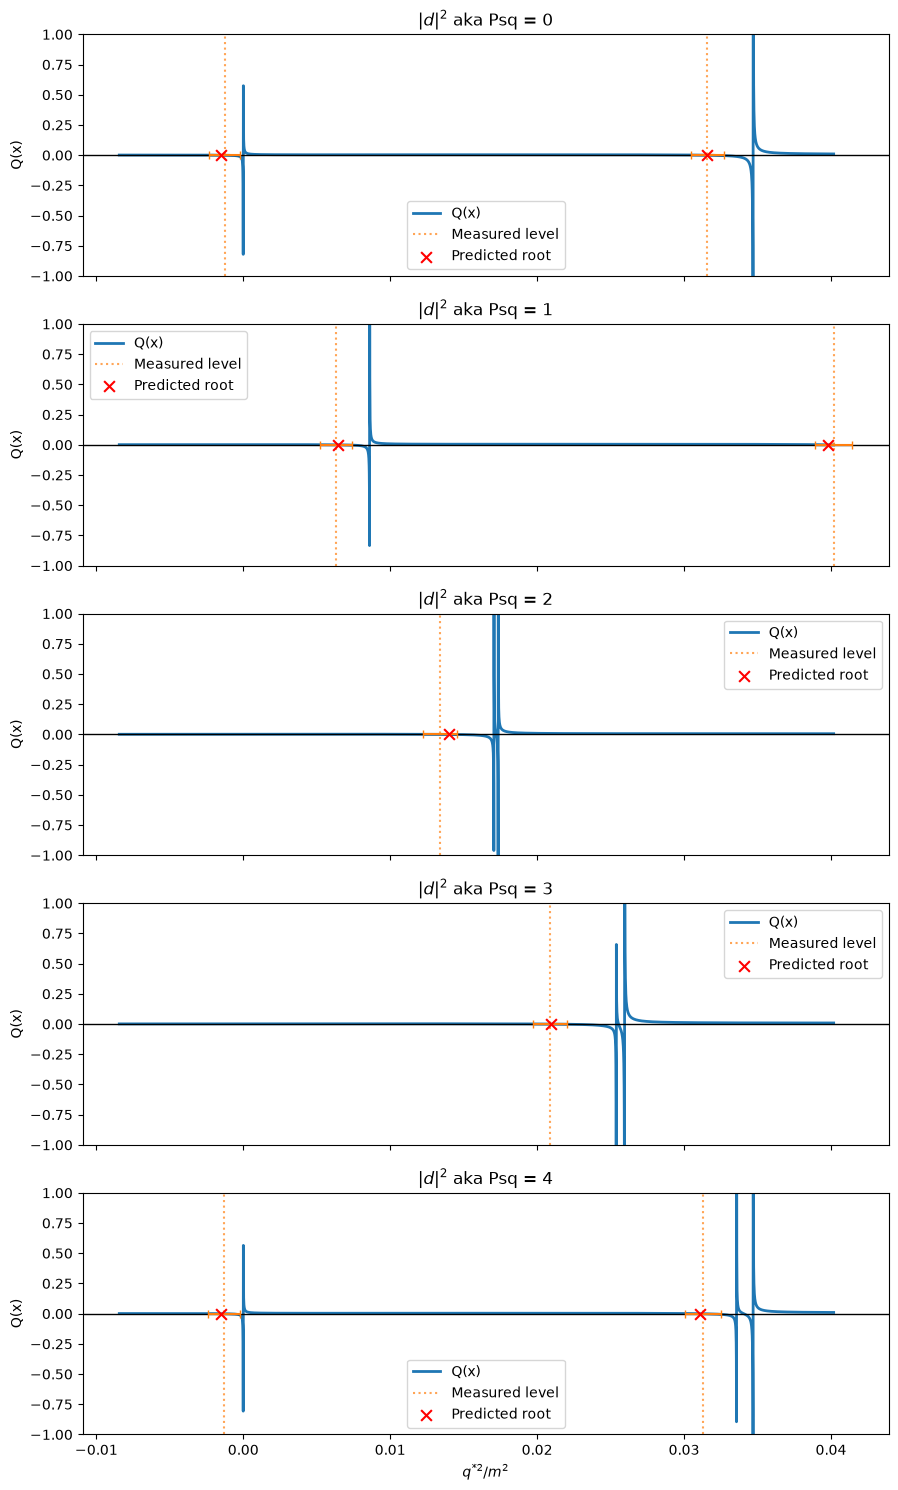

In [69]:
def Ecm_to_x(Ecm):
    Ecm = np.asarray(Ecm)
    q2 = Ecm**2 / 4.0 - m**2
    return q2 / m**2


a_plot = best_a      # or choose any values you want
r_plot = best_r

fig, axes = plt.subplots(
    5, 1,
    figsize=(9, 15),
    sharex=True
)

for Psq, ax in enumerate(axes):

    # Quantization condition on the scan grid
    Q = quantization_grid(a_plot, r_plot, Psq)

    # Predicted finite-volume energy levels
    roots = find_zeros_in_grid(
        Q,
        Ecm_grid,
        pole_Dict_All[Psq],
        Psq
    )

    # Convert to x = q*²/m²
    x_grid = Ecm_to_x(Ecm_grid)
    x_roots = Ecm_to_x(roots)

    # Plot quantization condition
    ax.plot(
        x_grid,
        Q,
        lw=2,
        label="Q(x)"
    )

    ax.axhline(
        0,
        color="black",
        lw=1
    )

    # Plot measured lattice energies
    info = sector_data[Psq]

    for i, (Ecm, sigma) in enumerate(zip(info["Ecm"], info["sigma"])):

        x = Ecm_to_x(Ecm)

        ax.axvline(
            x,
            color="tab:orange",
            ls=":",
            alpha=0.7,
            label="Measured level" if i == 0 else None
        )

        ax.errorbar(
            x,
            0,
            xerr=sigma * Ecm / (2*m**2),   # approximate propagation
            fmt="none",
            color="tab:orange",
            capsize=3
        )

    # Plot predicted roots
    ax.scatter(
        x_roots,
        np.zeros_like(x_roots),
        marker="x",
        s=60,
        color="red",
        label="Predicted root",
        zorder=5
    )

    ax.set_title(f"$|d|^2$ aka Psq = {Psq}")
    ax.set_ylabel("Q(x)")
    ax.set_ylim(-1, 1)
    ax.legend()

axes[-1].set_xlabel(r"$q^{*2}/m^2$")

plt.tight_layout()
plt.show()

TypeError: find_zeros_in_grid() missing 1 required positional argument: 'Psq'

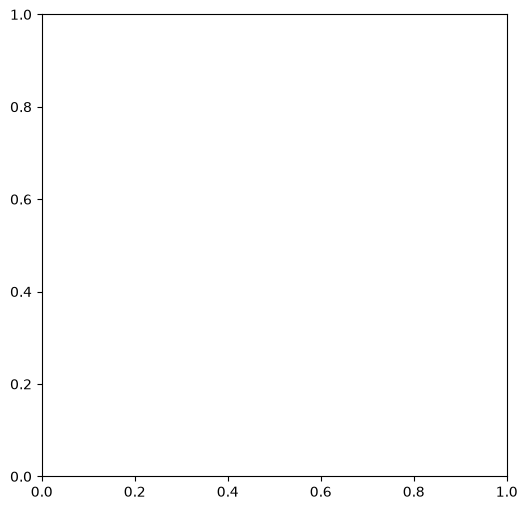

In [70]:
fig, ax = plt.subplots(figsize=(6,6))

for Psq in range(5):

    info = sector_data[Psq]

    Q = quantization_grid(best_a, best_r, Psq)

    roots = find_zeros_in_grid(
        Q,
        Ecm_grid,
        pole_Dict_All[Psq]
    )

    observed = np.sort(info["Ecm"])
    predicted = np.sort(roots[:len(observed)])

    ax.scatter(
        observed,
        predicted,
        label=f"$|d|^2={Psq}$"
    )

lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1])
]

ax.plot(lims, lims, 'k--')
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel("Observed $E_{cm}$")
ax.set_ylabel("Predicted $E_{cm}$")
ax.set_title("Fit quality")
ax.legend()

plt.tight_layout()
plt.show()